# Detecting Malicious URLs with Lexical Features
**Arturo Gourentchik, Lachlan Carlsen, Mark Lester Apuya**  
Department of Computer Science – San Diego State University  
CS 549: Machine Learning. 
{agourentchik7972, lcarlsen7906, mapuya5582}@sdsu.edu  

## Section 1: Import Libraries
Import all necessary Python libraries for data manipulation, URL parsing, machine learning, model evaluation, and visualization.

In [1]:
import pandas as pd
import numpy as np

from urllib.parse import urlparse
import tldextract

from scipy.stats import entropy
from collections import Counter
import math

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    train_test_split,
    GroupKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.utils.class_weight import compute_class_weight

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

import time

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')

## Section 2: Load Data & Overiew 
Load the malicious/benign URL dataset and perform initial exploration to understand its structure, size, and data types.

### 2.1 Load Dataset
Load the CSV dataset containing URLs and their labels (benign=0, malicious=1).

In [2]:
# Load the dataset
df = pd.read_csv('urldata.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 10 rows:")
df.head(10)

Dataset Shape: (450176, 4)

Column Names: ['Unnamed: 0', 'url', 'label', 'result']

Data Types:
Unnamed: 0     int64
url           object
label         object
result         int64
dtype: object

First 10 rows:


,Unnamed: 0,url,label,result
0,0,https://www.google.com,benign,0
1,1,https://www.youtube.com,benign,0
2,2,https://www.facebook.com,benign,0
3,3,https://www.baidu.com,benign,0
4,4,https://www.wikipedia.org,benign,0
5,5,https://www.reddit.com,benign,0
6,6,https://www.yahoo.com,benign,0
7,7,https://www.google.co.in,benign,0
8,8,https://www.qq.com,benign,0
9,9,https://www.amazon.com,benign,0


### 2.2 Exploratory Data Analysis
Examine dataset statistics, check for missing values, and understand the distribution of features.

## DATASET OVERVIEW


Total URLs: 450,176

Missing Values:
Unnamed: 0    0
url           0
label         0
result        0
dtype: int64

Duplicate Rows: 0


## CLASS DISTRIBUTION


Label Counts:
label
benign       345738
malicious    104438
Name: count, dtype: int64

Label Proportions:
label
benign       0.768006
malicious    0.231994
Name: proportion, dtype: float64


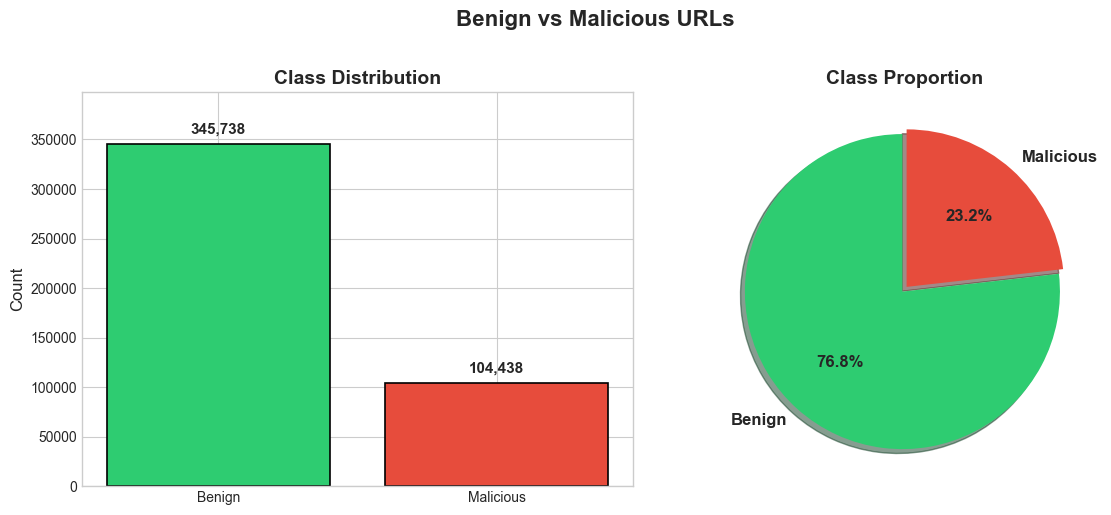

In [3]:
# Basic statistics
from IPython.display import display, Markdown, HTML
display(Markdown("## DATASET OVERVIEW"))

print(f"\nTotal URLs: {len(df):,}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum():,}")

# Class distribution
from IPython.display import display, Markdown, HTML
display(Markdown("## CLASS DISTRIBUTION"))

print(f"\nLabel Counts:\n{df['label'].value_counts()}")
print(f"\nLabel Proportions:\n{df['label'].value_counts(normalize=True)}")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']  # Green for benign, Red for malicious
counts = df['label'].value_counts().sort_index()
bars = axes[0].bar(['Benign', 'Malicious'], counts.values, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_ylim(0, counts.max() * 1.15)

# Add count labels on bars
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max()*0.02, 
                 f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Benign', 'Malicious'], colors=colors, autopct='%1.1f%%',
            startangle=90, explode=(0.02, 0.02), shadow=True,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Benign vs Malicious URLs', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.3 Sample URLs and Labels
Display example URLs from both benign and malicious classes to understand the data patterns.

In [4]:
# Sample benign URLs
from IPython.display import display, Markdown, HTML
display(Markdown("## SAMPLE BENIGN URLs"))
benign_urls = df[df['result'] == 0]['url'].sample(5, random_state=42)
for url in benign_urls:
    print(url)

# Sample malicious URLs
from IPython.display import display, Markdown, HTML
display(Markdown("## SAMPLE MALICIOUS URLs"))
malicious_urls = df[df['result'] == 1]['url'].sample(5, random_state=42)
for url in malicious_urls:
    print(url)

# PRELIMINARY LEXICAL PATTERN ANALYSIS
from IPython.display import display, Markdown, HTML
display(Markdown("## PRELIMINARY LEXICAL PATTERN ANALYSIS"))

# Create temporary features for exploration
temp_df = df.copy()
temp_df['url_length'] = temp_df['url'].apply(len)
temp_df['num_dots'] = temp_df['url'].apply(lambda x: x.count('.'))
temp_df['num_slashes'] = temp_df['url'].apply(lambda x: x.count('/'))
temp_df['num_digits'] = temp_df['url'].apply(lambda x: sum(c.isdigit() for c in x))
temp_df['num_special'] = temp_df['url'].apply(lambda x: sum(c in '-_@?&=%#' for c in x))
temp_df['has_https'] = temp_df['url'].apply(lambda x: 1 if x.startswith('https') else 0)
temp_df['has_ip'] = temp_df['url'].apply(lambda x: 1 if any(c.isdigit() and '.' in x[max(0,x.find(c)-3):x.find(c)+4] for c in x) else 0)

# Compare means by class
features = ['url_length', 'num_dots', 'num_slashes', 'num_digits', 'num_special', 'has_https']
comparison = temp_df.groupby('result')[features].mean().T
comparison.columns = ['Benign', 'Malicious']
comparison['Difference'] = comparison['Malicious'] - comparison['Benign']
print("\nMean Feature Values by Class:")
print(comparison.round(2))

# HTTPS usage comparison
from IPython.display import display, Markdown, HTML
display(Markdown("## HTTPS USAGE BY CLASS"))
https_stats = temp_df.groupby('result')['has_https'].mean() * 100
print(f"Benign URLs using HTTPS: {https_stats[0]:.1f}%")
print(f"Malicious URLs using HTTPS: {https_stats[1]:.1f}%")

# www. usage comparison
from IPython.display import display, Markdown, HTML
display(Markdown("## www. USAGE BY CLASS"))
temp_df['has_www'] = temp_df['url'].apply(lambda x: 1 if 'www.' in x else 0)
www_stats = temp_df.groupby('result')['has_www'].mean() * 100
print(f"Benign URLs using www: {www_stats[0]:.1f}%")
print(f"Malicious URLs using www: {www_stats[1]:.1f}%")

del temp_df

## SAMPLE BENIGN URLs

https://www.yelp.com/biz/stone-mountain-clay-and-glaze-tucker
https://www.ivanhill5478.blogspot.com/
https://www.facebook.com/people/Reggie-Walton/1070104441
https://www.freepages.genealogy.rootsweb.ancestry.com/~dwdrury/abell/index3.htm
https://www.manchester.edu/Athletics/basketballm/moreNews.htm


## SAMPLE MALICIOUS URLs

http://educatingwellness.com/ServiceE/78c95/home?webapps/mpp/merchant
http://grupodoma.com.mx/dropbox/mail.126.com/accounts.php
http://cke8q1.lucirabydevpps.info/zla4u55jxc\nwww.doblatuproductividad.com/000ded60ea040d013384ba6eac24fdf1.php?q=00d99394125a37085e8f4f81ddee3c18
http://www.dimplexx.net/offer001/
http://rubialage.com.br/store/css/


## PRELIMINARY LEXICAL PATTERN ANALYSIS


Mean Feature Values by Class:
             Benign  Malicious  Difference
url_length    58.48      66.05        7.57
num_dots       2.65       2.52       -0.14
num_slashes    4.30       4.93        0.63
num_digits     3.28       7.23        3.96
num_special    2.42       1.91       -0.51
has_https      1.00       0.06       -0.94


## HTTPS USAGE BY CLASS

Benign URLs using HTTPS: 100.0%
Malicious URLs using HTTPS: 6.2%


## www. USAGE BY CLASS

Benign URLs using www: 99.8%
Malicious URLs using www: 14.8%


## Section 3: Data Preprocessing
Clean, normalize, and transform raw URLs into a structured feature set suitable for machine learning models.

### 3.1 Handling Missing or Invalid URLs
Identify and remove records with missing, empty, or unparseable URL strings.

In [5]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 3.1 HANDLING MISSING OR INVALID URLs"))

# INPUT
print(f"\n[INPUT] Shape: {df.shape}")
print(f"[INPUT] Sample:\n{df[['url', 'label', 'result']].head(3)}")

# Track initial count
initial_count = len(df)

# Remove rows with missing URLs
df = df.dropna(subset=['url'])

# Remove empty strings
df = df[df['url'].str.strip() != '']

# Remove URLs that can't be parsed
def is_valid_url(url):
    try:
        result = urlparse(url)
        return all([result.scheme or url.startswith('www'), len(url) > 5])
    except:
        return False

df = df[df['url'].apply(is_valid_url)]

# OUTPUT
removed_count = initial_count - len(df)
print(f"\n[OUTPUT] Shape: {df.shape}")
print(f"[OUTPUT] Removed: {removed_count:,} invalid/missing URLs")
print(f"[OUTPUT] Remaining: {len(df):,} valid URLs")

## 3.1 HANDLING MISSING OR INVALID URLs


[INPUT] Shape: (450176, 4)
[INPUT] Sample:
                        url   label  result
0    https://www.google.com  benign       0
1   https://www.youtube.com  benign       0
2  https://www.facebook.com  benign       0

[OUTPUT] Shape: (450175, 4)
[OUTPUT] Removed: 1 invalid/missing URLs
[OUTPUT] Remaining: 450,175 valid URLs


### 3.2 Remove Duplicate URLs
Eliminate duplicate URLs to prevent data leakage and training bias.

In [6]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 3.2 REMOVE DUPLICATE URLs"))

# INPUT
print(f"\n[INPUT] Shape: {df.shape}")
print(f"[INPUT] Duplicate count: {df.duplicated(subset=['url']).sum():,}")

# Track initial count
initial_count = len(df)

# Remove exact duplicate URLs (keep first occurrence)
df = df.drop_duplicates(subset=['url'], keep='first')

# Reset index
df = df.reset_index(drop=True)

# OUTPUT
removed_count = initial_count - len(df)
print(f"\n[OUTPUT] Shape: {df.shape}")
print(f"[OUTPUT] Removed: {removed_count:,} duplicate URLs")
print(f"[OUTPUT] Remaining: {len(df):,} unique URLs")

## 3.2 REMOVE DUPLICATE URLs


[INPUT] Shape: (450175, 4)
[INPUT] Duplicate count: 0

[OUTPUT] Shape: (450175, 4)
[OUTPUT] Removed: 0 duplicate URLs
[OUTPUT] Remaining: 450,175 unique URLs


### 3.3 URL Normalization 
Standardize URLs by lowercasing, removing fragments, stripping default ports, and collapsing repeated slashes.

In [7]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 3.3 URL NORMALIZATION"))

# INPUT
print(f"\n[INPUT] Shape: {df.shape}")
print(f"[INPUT] Sample URLs:")
for url in df['url'].head(3):
    print(f"  {url}")

def normalize_url(url):
    # Lowercase the URL
    url = url.lower()
    
    # Remove fragments
    if '#' in url:
        url = url.split('#')[0]
    
    # Remove trailing slashes
    url = url.rstrip('/')
    
    # Remove default ports (:80 for http, :443 for https)
    url = url.replace(':80/', '/').replace(':443/', '/')
    url = url.replace(':80', '').replace(':443', '')
    
    # Collapse multiple slashes
    if '://' in url:
        protocol, rest = url.split('://', 1)
        rest = '/'.join(filter(None, rest.split('/')))
        url = f"{protocol}://{rest}"
    
    return url

# Apply normalization
df['url_normalized'] = df['url'].apply(normalize_url)

# OUTPUT
print(f"\n[OUTPUT] Shape: {df.shape}")
print(f"[OUTPUT] New column added: 'url_normalized'")

## 3.3 URL NORMALIZATION


[INPUT] Shape: (450175, 4)
[INPUT] Sample URLs:
  https://www.google.com
  https://www.youtube.com
  https://www.facebook.com

[OUTPUT] Shape: (450175, 5)
[OUTPUT] New column added: 'url_normalized'


Sample Modified URLs

In [8]:
# Find modified URLs
modified_urls = df[df['url'] != df['url_normalized']]
print(f"[OUTPUT] URLs modified: {len(modified_urls):,} ({len(modified_urls)/len(df)*100:.2f}%)")

# Modified URLs
if len(modified_urls) > 0:
    print(f"\n[OUTPUT] Sample MODIFIED URLs:")
    for i, row in modified_urls[['url', 'url_normalized']].sample(min(5, len(modified_urls)), random_state=42).iterrows():
        print(f"  Original:   {row['url']}")
        print(f"  Normalized: {row['url_normalized']}\n")
else:
    print(f"\n[OUTPUT] No URLs required normalization changes.")
    print(f"[OUTPUT] Sample URLs (unchanged):")
    for i, row in df[['url', 'url_normalized']].sample(3, random_state=42).iterrows():
        print(f"  {row['url']}")

print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 10 rows:")
df.head(10)

[OUTPUT] URLs modified: 258,697 (57.47%)

[OUTPUT] Sample MODIFIED URLs:
  Original:   https://www.encyclopedia.com/topic/Vietnam_War.aspx
  Normalized: https://www.encyclopedia.com/topic/vietnam_war.aspx

  Original:   https://www.wn.com/Frederick_Todd
  Normalized: https://www.wn.com/frederick_todd

  Original:   https://www.canadiansoccernews.com/content.php?1087-Nick-Dasovic-and-Toronto-FC-part-ways
  Normalized: https://www.canadiansoccernews.com/content.php?1087-nick-dasovic-and-toronto-fc-part-ways

  Original:   https://www.acgsi.org/genweb/
  Normalized: https://www.acgsi.org/genweb

  Original:   https://www.en.wikipedia.org/wiki/Angela_Tong
  Normalized: https://www.en.wikipedia.org/wiki/angela_tong


Column Names: ['Unnamed: 0', 'url', 'label', 'result', 'url_normalized']

Data Types:
Unnamed: 0         int64
url               object
label             object
result             int64
url_normalized    object
dtype: object

First 10 rows:


,Unnamed: 0,url,label,result,url_normalized
0,0,https://www.google.com,benign,0,https://www.google.com
1,1,https://www.youtube.com,benign,0,https://www.youtube.com
2,2,https://www.facebook.com,benign,0,https://www.facebook.com
3,3,https://www.baidu.com,benign,0,https://www.baidu.com
4,4,https://www.wikipedia.org,benign,0,https://www.wikipedia.org
5,5,https://www.reddit.com,benign,0,https://www.reddit.com
6,6,https://www.yahoo.com,benign,0,https://www.yahoo.com
7,7,https://www.google.co.in,benign,0,https://www.google.co.in
8,8,https://www.qq.com,benign,0,https://www.qq.com
9,9,https://www.amazon.com,benign,0,https://www.amazon.com


### 3.4 Lexical Feature Extraction
Extract numerical features from URL strings without fetching page content.

#### 3.4.1 Length Features
Calculate length-based features: total URL length, host length, path length, and query length.

In [9]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 3.4.1 LENGTH FEATURES"))

# INPUT
print(f"\n[INPUT] Shape: {df.shape}")
print(f"[INPUT] Columns: {df.columns.tolist()}")

def extract_length_features(url):
    """Extract length-based features from URL"""
    parsed = urlparse(url)
    
    return {
        'url_length': len(url),
        'host_length': len(parsed.netloc),
        'path_length': len(parsed.path),
        'query_length': len(parsed.query)
    }

# Apply feature extraction to all URLs
length_features = df['url_normalized'].apply(extract_length_features).apply(pd.Series)

# Add to dataframe
df = pd.concat([df, length_features], axis=1)

# OUTPUT
print(f"\n[OUTPUT] Shape: {df.shape}")
print(f"[OUTPUT] New features: {length_features.columns.tolist()}")
print(f"\n[OUTPUT] Features:")
print(df[['url_length', 'host_length', 'path_length', 'query_length']].describe().round(2))

## 3.4.1 LENGTH FEATURES


[INPUT] Shape: (450175, 5)
[INPUT] Columns: ['Unnamed: 0', 'url', 'label', 'result', 'url_normalized']

[OUTPUT] Shape: (450175, 9)
[OUTPUT] New features: ['url_length', 'host_length', 'path_length', 'query_length']

[OUTPUT] Features:
       url_length  host_length  path_length  query_length
count   450175.00    450175.00    450175.00     450175.00
mean        59.93        19.29        27.17          5.53
std         37.53         6.69        24.76         28.31
min          5.00         0.00         0.00          0.00
25%         40.00        15.00        11.00          0.00
50%         52.00        18.00        22.00          0.00
75%         71.00        22.00        38.00          0.00
max       2314.00       240.00      1897.00       2245.00


#### 3.4.2 Count Features
Count occurrences of special characters, digits, subdomain levels, and path segments.

In [10]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 3.4.2 COUNT FEATURES"))

# INPUT
print(f"\n[INPUT] Shape: {df.shape}")

def extract_count_features(url):
    """Count occurrences of special characters and patterns"""
    parsed = urlparse(url)
    ext = tldextract.extract(url)
    
    return {
        'num_dots': url.count('.'), # of dots
        'num_hyphens': url.count('-'), # of hyphens
        'num_underscores': url.count('_'), # of underscores
        'num_slashes': url.count('/'), # of slashes
        'num_question_marks': url.count('?'), # of question marks
        'num_equals': url.count('='), # of equals signs
        'num_ampersands': url.count('&'), # of ampersands
        'num_at_symbols': url.count('@'), # of at symbols
        'num_digits': sum(c.isdigit() for c in url), # of digits
        'num_letters': sum(c.isalpha() for c in url), # of letters
        'num_subdomains': len(ext.subdomain.split('.')) if ext.subdomain else 0, # of subdomains
        'num_path_segments': len([s for s in parsed.path.split('/') if s]), # of path segments
        'num_params': len(parsed.query.split('&')) if parsed.query else 0 # of query parameters
        # ADD more count features as needed
    }   

# Apply feature extraction to all URLs
count_features = df['url_normalized'].apply(extract_count_features).apply(pd.Series)

# Add to dataframe
df = pd.concat([df, count_features], axis=1)

# OUTPUT
print(f"\n[OUTPUT] Shape: {df.shape}")
print(f"[OUTPUT] New features: {count_features.columns.tolist()}")
print(f"\n[OUTPUT] Feature:")
print(count_features.describe().round(2))

## 3.4.2 COUNT FEATURES


[INPUT] Shape: (450175, 9)

[OUTPUT] Shape: (450175, 22)
[OUTPUT] New features: ['num_dots', 'num_hyphens', 'num_underscores', 'num_slashes', 'num_question_marks', 'num_equals', 'num_ampersands', 'num_at_symbols', 'num_digits', 'num_letters', 'num_subdomains', 'num_path_segments', 'num_params']

[OUTPUT] Feature:
        num_dots  num_hyphens  num_underscores  num_slashes  \
count  450175.00    450175.00        450175.00    450175.00   
mean        2.62         1.25             0.42         4.17   
std         1.14         2.57             1.34         1.61   
min         0.00         0.00             0.00         0.00   
25%         2.00         0.00             0.00         3.00   
50%         2.00         0.00             0.00         4.00   
75%         3.00         1.00             0.00         5.00   
max        32.00        42.00           200.00        45.00   

       num_question_marks  num_equals  num_ampersands  num_at_symbols  \
count           450175.00   450175.00      

#### 3.4.3 Ratio Features
Compute ratios: digits-to-length, symbols-to-length, uppercase-to-lowercase.

In [11]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 3.4.3 RATIO FEATURES"))

# INPUT
print(f"\n[INPUT] Shape: {df.shape}")

# Calculate ratio features (avoid division by zero)
df['digit_ratio'] = df['num_digits'] / df['url_length'].replace(0, 1) # of digits / url length
df['letter_ratio'] = df['num_letters'] / df['url_length'].replace(0, 1) # of letters / url length
df['symbol_ratio'] = (df['num_hyphens'] + df['num_underscores'] + df['num_at_symbols']) / df['url_length'].replace(0, 1) # of symbols / url length
df['digit_letter_ratio'] = df['num_digits'] / df['num_letters'].replace(0, 1) # of digits / letters
df['path_url_ratio'] = df['path_length'] / df['url_length'].replace(0, 1) # path length / url length
df['query_url_ratio'] = df['query_length'] / df['url_length'].replace(0, 1) # query length / url length
df['host_url_ratio'] = df['host_length'] / df['url_length'].replace(0, 1) # host length / url length
# Add more ratio features as needed

ratio_features = ['digit_ratio', 'letter_ratio', 'symbol_ratio', 'digit_letter_ratio', 
                  'path_url_ratio', 'query_url_ratio', 'host_url_ratio']

# OUTPUT
print(f"\n[OUTPUT] Shape: {df.shape}")
print(f"[OUTPUT] New features: {ratio_features}")
print(f"\n[OUTPUT] Features:")
print(df[ratio_features].describe().round(4))

## 3.4.3 RATIO FEATURES


[INPUT] Shape: (450175, 22)

[OUTPUT] Shape: (450175, 29)
[OUTPUT] New features: ['digit_ratio', 'letter_ratio', 'symbol_ratio', 'digit_letter_ratio', 'path_url_ratio', 'query_url_ratio', 'host_url_ratio']

[OUTPUT] Features:
       digit_ratio  letter_ratio  symbol_ratio  digit_letter_ratio  \
count  450175.0000   450175.0000   450175.0000         450175.0000   
mean        0.0558        0.7657        0.0216              0.0926   
std         0.0815        0.0853        0.0280              0.2100   
min         0.0000        0.1046        0.0000              0.0000   
25%         0.0000        0.7297        0.0000              0.0000   
50%         0.0149        0.7895        0.0123              0.0182   
75%         0.0882        0.8235        0.0357              0.1207   
max         0.8100        0.9878        0.8410              5.5000   

       path_url_ratio  query_url_ratio  host_url_ratio  
count     450175.0000      450175.0000     450175.0000  
mean           0.4036       

#### 3.4.4 Entropy Features
Calculate Shannon entropy for the full URL and path to measure randomness/complexity.

In [12]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 3.4.4 ENTROPY FEATURES"))

# INPUT
print(f"\n[INPUT] Shape: {df.shape}")

def calculate_entropy(text):
    """Calculate Shannon entropy of a string"""
    if not text:
        return 0.0
    freq = Counter(text)
    probs = [count / len(text) for count in freq.values()]
    return entropy(probs, base=2) # Shannon entropy

def extract_entropy_features(url):
    """Extract entropy-based features"""
    parsed = urlparse(url)
    ext = tldextract.extract(url)
    
    return {
        'url_entropy': calculate_entropy(url), # entropy of entire URL
        'host_entropy': calculate_entropy(parsed.netloc), # entropy of host
        'path_entropy': calculate_entropy(parsed.path), # entropy of path
        'domain_entropy': calculate_entropy(ext.domain) # entropy of domain
    }

# Apply feature extraction to all URLs
entropy_features = df['url_normalized'].apply(extract_entropy_features).apply(pd.Series)

# Add to dataframe
df = pd.concat([df, entropy_features], axis=1)

entropy_cols = ['url_entropy', 'host_entropy', 'path_entropy', 'domain_entropy']

# OUTPUT
print(f"\n[OUTPUT] Shape: {df.shape}")
print(f"[OUTPUT] New features: {entropy_cols}")
print(f"\n[OUTPUT] Features:")
print(df[entropy_cols].describe().round(4))

## 3.4.4 ENTROPY FEATURES


[INPUT] Shape: (450175, 29)

[OUTPUT] Shape: (450175, 33)
[OUTPUT] New features: ['url_entropy', 'host_entropy', 'path_entropy', 'domain_entropy']

[OUTPUT] Features:
       url_entropy  host_entropy  path_entropy  domain_entropy
count  450175.0000   450175.0000   450175.0000     450175.0000
mean        4.2694        3.3731        3.1850          2.7260
std         0.2807        0.3365        1.3675          0.5576
min         1.3258        0.0000        0.0000          0.0000
25%         4.0902        3.1820        3.0106          2.5000
50%         4.2637        3.3736        3.6753          2.7500
75%         4.4612        3.6069        4.0535          3.1219
max         5.3661        5.0377        5.1905          4.7046


#### 3.4.5 Binary Flag Features
Create binary indicators: HTTPS presence, IP address in host, suspicious extensions, and keyword flags.

In [13]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 3.4.5 BINARY FLAG FEATURES"))

# INPUT
print(f"\n[INPUT] Shape: {df.shape}")

import re

def extract_binary_features(url):
    """Extract binary indicator features"""
    parsed = urlparse(url)
    
    # IP address pattern
    ip_pattern = r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}' # IPv4 pattern 
    
    # Suspicious keywords
    suspicious_words = ['secure', 'login', 'signin', 'bank', 'account', 'update', 
                        'verify', 'password', 'confirm', 'suspend', 'alert'] # common phishing words... Add more as needed
    
    # Suspicious extensions
    suspicious_ext = ['.exe', '.php', '.js', '.bat', '.cmd', '.scr'] # common executable/script extensions... Add more as needed
    
    # URL shorteners
    shorteners = ['bit.ly', 'tinyurl', 't.co', 'goo.gl', 'ow.ly', 'is.gd', 'buff.ly'] # common URL shorteners... Add more as needed

    # ADD more binary features as needed
    
    return {
        'has_https': 1 if url.startswith('https') else 0, # of https
        'has_http': 1 if url.startswith('http://') else 0, # of http
        'has_ip_address': 1 if re.search(ip_pattern, parsed.netloc) else 0, # presence of IP address
        'has_at_symbol': 1 if '@' in url else 0, # presence of '@' symbol
        'has_port': 1 if ':' in parsed.netloc and not parsed.netloc.startswith('[') else 0, # presence of port number
        'has_suspicious_word': 1 if any(word in url.lower() for word in suspicious_words) else 0, # presence of suspicious words
        'has_suspicious_ext': 1 if any(ext in url.lower() for ext in suspicious_ext) else 0, # presence of suspicious extensions
        'is_shortened': 1 if any(shortener in url.lower() for shortener in shorteners) else 0, # is URL shortened
        'has_subdomain': 1 if tldextract.extract(url).subdomain else 0, # presence of subdomain
        'has_www': 1 if 'www.' in url.lower() else 0 # presence of www
        # Add more binary features as needed
    }

# Apply feature extraction to all URLs
binary_features = df['url_normalized'].apply(extract_binary_features).apply(pd.Series)

# Add to dataframe
df = pd.concat([df, binary_features], axis=1)

binary_cols = binary_features.columns.tolist()

# OUTPUT
print(f"\n[OUTPUT] Shape: {df.shape}")
print(f"[OUTPUT] New features: {binary_cols}")
print(f"\n[OUTPUT] Feature distribution:")
print(df[binary_cols].sum().to_frame('Count').T)
print(f"\n[OUTPUT] Percentage of URLs with each flag:")
print((df[binary_cols].mean() * 100).round(2).to_frame('%').T)

## 3.4.5 BINARY FLAG FEATURES


[INPUT] Shape: (450175, 33)

[OUTPUT] Shape: (450175, 43)
[OUTPUT] New features: ['has_https', 'has_http', 'has_ip_address', 'has_at_symbol', 'has_port', 'has_suspicious_word', 'has_suspicious_ext', 'is_shortened', 'has_subdomain', 'has_www']

[OUTPUT] Feature distribution:
       has_https  has_http  has_ip_address  has_at_symbol  has_port  \
Count     352220     97946            3974           2952      1445   

       has_suspicious_word  has_suspicious_ext  is_shortened  has_subdomain  \
Count                20232               46894         26556         380002   

       has_www  
Count   360488  

[OUTPUT] Percentage of URLs with each flag:
   has_https  has_http  has_ip_address  has_at_symbol  has_port  \
%      78.24     21.76            0.88           0.66      0.32   

   has_suspicious_word  has_suspicious_ext  is_shortened  has_subdomain  \
%                 4.49               10.42           5.9          84.41   

   has_www  
%    80.08  


### 3.5 Categorical Feature Encoding
One-hot encode categorical features such as protocol scheme and TLD bucket.

In [14]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 3.5 CATEGORICAL FEATURE ENCODING"))

# INPUT
print(f"\n[INPUT] Shape: {df.shape}")

def extract_categorical_features(url):
    """Extract categorical features from URL"""
    parsed = urlparse(url)
    ext = tldextract.extract(url)
    
    # Protocol scheme
    scheme = parsed.scheme if parsed.scheme else 'none' # https, http, ftp...
    
    # TLD
    tld = ext.suffix if ext.suffix else 'unknown' # com, org, net, co.uk...
    
    return {
        'scheme': scheme,
        'tld': tld
    }

# Extract categorical features
cat_features = df['url_normalized'].apply(extract_categorical_features).apply(pd.Series)

# Get TLD frequency and bucket rare TLDs
tld_counts = cat_features['tld'].value_counts()
common_tlds = tld_counts[tld_counts >= 100].index.tolist()  # TLDs with 100+ occurrences
cat_features['tld_bucket'] = cat_features['tld'].apply(lambda x: x if x in common_tlds else 'other')

# One-hot encode scheme
scheme_dummies = pd.get_dummies(cat_features['scheme'], prefix='scheme')

# One-hot encode TLD bucket
tld_dummies = pd.get_dummies(cat_features['tld_bucket'], prefix='tld')

# Add to dataframe
df = pd.concat([df, scheme_dummies, tld_dummies], axis=1)

# Store categorical column names
scheme_cols = scheme_dummies.columns.tolist()
tld_cols = tld_dummies.columns.tolist()
categorical_cols = scheme_cols + tld_cols

# OUTPUT
print(f"\n[OUTPUT] Shape: {df.shape}")
print(f"[OUTPUT] Scheme features: {scheme_cols}")
print(f"[OUTPUT] TLD features ({len(tld_cols)}): {tld_cols[:10]}...")
print(f"\n[OUTPUT] Scheme distribution:")
print(cat_features['scheme'].value_counts())
print(f"\n[OUTPUT] Top 10 TLD buckets:")
print(cat_features['tld_bucket'].value_counts().head(10))

## 3.5 CATEGORICAL FEATURE ENCODING


[INPUT] Shape: (450175, 43)

[OUTPUT] Shape: (450175, 139)
[OUTPUT] Scheme features: ['scheme_ftp', 'scheme_http', 'scheme_https', 'scheme_httpss']
[OUTPUT] TLD features (92): ['tld_ac.uk', 'tld_ae', 'tld_at', 'tld_be', 'tld_biz', 'tld_by', 'tld_ca', 'tld_cc', 'tld_cf', 'tld_ch']...

[OUTPUT] Scheme distribution:
scheme
https     352185
http       97947
httpss        35
ftp            8
Name: count, dtype: int64

[OUTPUT] Top 10 TLD buckets:
tld_bucket
com        316427
org         38396
net         16584
ca           8824
other        7970
edu          6968
co.uk        5213
unknown      4380
ru           3739
com.br       3389
Name: count, dtype: int64


### 3.6 Feature Scaling for Linear Models
Apply StandardScaler (z-score normalization) to continuous features for linear models. Tree-based models use unscaled features.

In [15]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 3.6 FEATURE SCALING"))

# INPUT
print(f"\n[INPUT] Shape: {df.shape}")

# Define feature groups
length_cols = ['url_length', 'host_length', 'path_length', 'query_length'] # length features
count_cols = ['num_dots', 'num_hyphens', 'num_underscores', 'num_slashes', 
              'num_question_marks', 'num_equals', 'num_ampersands', 'num_at_symbols',
              'num_digits', 'num_letters', 'num_subdomains', 'num_path_segments', 'num_params'] # count features
ratio_cols = ['digit_ratio', 'letter_ratio', 'symbol_ratio', 'digit_letter_ratio',
              'path_url_ratio', 'query_url_ratio', 'host_url_ratio'] # ratio features
entropy_cols = ['url_entropy', 'host_entropy', 'path_entropy', 'domain_entropy'] # entropy features
binary_cols = ['has_https', 'has_http', 'has_ip_address', 'has_at_symbol', 
               'has_port', 'has_suspicious_word', 
               'has_suspicious_ext', 'is_shortened', 'has_subdomain', 'has_www'] # binary features

# Continuous features
continuous_cols = length_cols + count_cols + ratio_cols + entropy_cols 

# All feature columns
all_feature_cols = continuous_cols + binary_cols + categorical_cols

print(f"\n[OUTPUT] Feature groups:")
print(f"Continuous features (to scale): {len(continuous_cols)}")
print(f"Binary features: {len(binary_cols)}")
print(f"Categorical (one-hot): {len(categorical_cols)}")
print(f"Total features: {len(all_feature_cols)}")

# Prepare feature matrix X and target y
X = df[all_feature_cols].copy()
y = df['result'].copy()

print(f"\n[OUTPUT] X shape: {X.shape}")
print(f"[OUTPUT] y shape: {y.shape}")
print(f"[OUTPUT] y distribution:\n{y.value_counts()}")

## 3.6 FEATURE SCALING


[INPUT] Shape: (450175, 139)

[OUTPUT] Feature groups:
Continuous features (to scale): 28
Binary features: 10
Categorical (one-hot): 96
Total features: 134

[OUTPUT] X shape: (450175, 134)
[OUTPUT] y shape: (450175,)
[OUTPUT] y distribution:
result
0    345738
1    104437
Name: count, dtype: int64


### 3.7 Handling Class Imbalance 
Compute class weights to handle imbalanced data during model training.

In [16]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 3.7 HANDLING CLASS IMBALANCE"))

# INPUT
print(f"\n[INPUT] Class distribution:")
print(y.value_counts())
print(f"\n[INPUT] Class proportions:")
print(y.value_counts(normalize=True))

# Compute class weights
classes = np.array([0, 1])
class_weights_array = compute_class_weight('balanced', classes=classes, y=y)
class_weights = {0: class_weights_array[0], 1: class_weights_array[1]}

# Calculate imbalance ratio
imbalance_ratio = y.value_counts()[0] / y.value_counts()[1]

# OUTPUT
print(f"\n[OUTPUT] Imbalance ratio: {imbalance_ratio:.2f}:1")
print(f"[OUTPUT] Computed class weights:")
print(f"Class 0 (Benign): {class_weights[0]:.4f}")
print(f"Class 1 (Malicious): {class_weights[1]:.4f}")
print(f"\n[OUTPUT] Weights that will be used during model training to handle imbalance.")

## 3.7 HANDLING CLASS IMBALANCE


[INPUT] Class distribution:
result
0    345738
1    104437
Name: count, dtype: int64

[INPUT] Class proportions:
result
0    0.768008
1    0.231992
Name: proportion, dtype: float64

[OUTPUT] Imbalance ratio: 3.31:1
[OUTPUT] Computed class weights:
Class 0 (Benign): 0.6510
Class 1 (Malicious): 2.1552

[OUTPUT] Weights that will be used during model training to handle imbalance.


### 3.8 Domain-Aware Train/Validation/Test Split
Split data by registrable domain to prevent leakage from related URLs appearing in both train and test sets.

In [17]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 3.8 DOMAIN-AWARE TRAIN/VALIDATION/TEST SPLIT"))

# INPUT
print(f"\n[INPUT] X shape: {X.shape}")
print(f"[INPUT] y shape: {y.shape}")

# Extract available domain for grouping
df['registrable_domain'] = df['url_normalized'].apply(
    lambda x: tldextract.extract(x).registered_domain
)

# Handle empty domains
df['registrable_domain'] = df['registrable_domain'].replace('', 'unknown_domain')

# Get unique domains
unique_domains = df['registrable_domain'].unique()
print(f"\n[INFO] Unique registrable domains: {len(unique_domains):,}")

# Create domain to group mapping
domain_to_group = {domain: idx for idx, domain in enumerate(unique_domains)}
groups = df['registrable_domain'].map(domain_to_group).values

# Split domains into train/val/test
np.random.seed(42)
shuffled_domains = np.random.permutation(unique_domains)

# 70% train, 15% validation, 15% test (by domain) 
n_domains = len(shuffled_domains)
train_end = int(0.70 * n_domains)
val_end = int(0.85 * n_domains)

train_domains = set(shuffled_domains[:train_end])
val_domains = set(shuffled_domains[train_end:val_end])
test_domains = set(shuffled_domains[val_end:])

# Create masks
train_mask = df['registrable_domain'].isin(train_domains)
val_mask = df['registrable_domain'].isin(val_domains)
test_mask = df['registrable_domain'].isin(test_domains)

# Split data
X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

# Store groups for cross validation
groups_train = groups[train_mask]

# OUTPUT
print(f"\n[OUTPUT] Split by registrable domain to prevent data leakage:")
print(f"\nTraining set:")
print(f"Domains: {len(train_domains):,}")
print(f"Samples: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Class distribution: {dict(y_train.value_counts())}")

print(f"\nValidation set:")
print(f"Domains: {len(val_domains):,}")
print(f"Samples: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Class distribution: {dict(y_val.value_counts())}")

print(f"\nTest set:")
print(f"Domains: {len(test_domains):,}")
print(f"Samples: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print(f"Class distribution: {dict(y_test.value_counts())}")

# Verify no domain overlap
train_val_overlap = train_domains.intersection(val_domains)
train_test_overlap = train_domains.intersection(test_domains)
val_test_overlap = val_domains.intersection(test_domains)
print(f"\n[OUTPUT] Domain overlap verification:")
print(f"Train/Val overlap: {len(train_val_overlap)} domains")
print(f"Train/Test overlap: {len(train_test_overlap)} domains")
print(f"Val/Test overlap: {len(val_test_overlap)} domains")

## 3.8 DOMAIN-AWARE TRAIN/VALIDATION/TEST SPLIT


[INPUT] X shape: (450175, 134)
[INPUT] y shape: (450175,)

[INFO] Unique registrable domains: 131,037

[OUTPUT] Split by registrable domain to prevent data leakage:

Training set:
Domains: 91,725
Samples: 316,150 (70.2%)
Class distribution: {0: np.int64(241499), 1: np.int64(74651)}

Validation set:
Domains: 19,656
Samples: 58,085 (12.9%)
Class distribution: {0: np.int64(44259), 1: np.int64(13826)}

Test set:
Domains: 19,656
Samples: 75,940 (16.9%)
Class distribution: {0: np.int64(59980), 1: np.int64(15960)}

[OUTPUT] Domain overlap verification:
Train/Val overlap: 0 domains
Train/Test overlap: 0 domains
Val/Test overlap: 0 domains


### 3.9 Data Preprocessing output

In [18]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 3.9 DATA PREPROCESSING OUTPUT"))

# INPUT
print(f"\n[INPUT] Shape: {df.shape}")

# Variables
print(f"\n[OUTPUT] Variables:")
required_vars = {
    'X': X,
    'y': y,
    'X_train': X_train,
    'X_val': X_val,
    'X_test': X_test,
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test,
    'class_weights': class_weights,
    'groups_train': groups_train,
    'continuous_cols': continuous_cols,
    'binary_cols': binary_cols,
    'categorical_cols': categorical_cols,
    'all_feature_cols': all_feature_cols
}

for var_name, var_value in required_vars.items():
    if isinstance(var_value, (pd.DataFrame, pd.Series, np.ndarray)):
        print(f"{var_name}: shape {var_value.shape}")
    elif isinstance(var_value, dict):
        print(f"{var_name}: {var_value}")
    elif isinstance(var_value, list):
        print(f"{var_name}: {len(var_value)} items")

## 3.9 DATA PREPROCESSING OUTPUT


[INPUT] Shape: (450175, 140)

[OUTPUT] Variables:
X: shape (450175, 134)
y: shape (450175,)
X_train: shape (316150, 134)
X_val: shape (58085, 134)
X_test: shape (75940, 134)
y_train: shape (316150,)
y_val: shape (58085,)
y_test: shape (75940,)
class_weights: {0: np.float64(0.6510348876895221), 1: np.float64(2.1552467037544165)}
groups_train: shape (316150,)
continuous_cols: 28 items
binary_cols: 10 items
categorical_cols: 96 items
all_feature_cols: 134 items


## Section 4: Model Pipelines

### 4.1 Logistic Regression
Linear baseline model with calibrated probabilities and interpretable feature coefficients.

In [19]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 4.1 LOGISTIC REGRESSION PIPELINE"))

# INPUT
print(f"\n[INPUT] Training data shape: {X_train.shape}")
print(f"[INPUT] Class weights: {class_weights}")

# Create preprocessing pipeline for Logistic Regression model
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), continuous_cols),
        ('passthrough', 'passthrough', binary_cols + categorical_cols)
    ],
    remainder='drop'
)

# Create pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight=class_weights,
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    ))
])

## 4.1 LOGISTIC REGRESSION PIPELINE


[INPUT] Training data shape: (316150, 134)
[INPUT] Class weights: {0: np.float64(0.6510348876895221), 1: np.float64(2.1552467037544165)}


### 4.2 Linear SVM
Margin-based classifier with probability calibration for reliable score outputs.

### 4.3 Random Forest
Ensemble tree model that captures non-linear patterns and feature interactions.

## Section 5: Hyperparameter Tuning (Grouped Cross-Validation)
Tune model hyperparameters using GroupKFold cross-validation to ensure domain-aware evaluation.

### 5.1 CV Setup
Configure GroupKFold with 5 folds, grouping by registrable domain to prevent data leakage.

In [20]:
# Logistic Regression groupKFold in 5.2

### 5.2 Logistic Regression Tuning
Grid search over regularization parameter and loss function.

In [21]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 5.2 LOGISTIC REGRESSION HYPERPARAMETER TUNING"))

# INPUT
print(f"[INPUT] Training samples: {len(X_train):,}")

# Define parameter grid
param_grid_lr = {
    'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],  # Regularization strength
    'classifier__penalty': ['l1', 'l2'],  # Regularization type
    'classifier__solver': ['liblinear']  # For l1 penalty
}

# Setup GroupKFold
gkf = GroupKFold(n_splits=5)

# Grid Search
print(f"\n[PROCESS] Running GridSearchCV...")
start_time = time.time()

grid_search_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid_lr,
    cv=gkf,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(X_train, y_train, groups=groups_train)

elapsed_time = time.time() - start_time

# OUTPUT
print(f"\n[OUTPUT] Grid Search completed in {elapsed_time:.2f} seconds")
print(f"[OUTPUT] Best parameters: {grid_search_lr.best_params_}")
print(f"[OUTPUT] Best CV F1 score: {grid_search_lr.best_score_:.4f}")

# Get best model
best_lr = grid_search_lr.best_estimator_

# Display top 5 parameter combinations
results_df = pd.DataFrame(grid_search_lr.cv_results_)
top_results = results_df.nlargest(5, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]
print(f"\n[OUTPUT] Top 5 parameter combinations:")
print(top_results.to_string(index=False))

## 5.2 LOGISTIC REGRESSION HYPERPARAMETER TUNING

[INPUT] Training samples: 316,150

[PROCESS] Running GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

[OUTPUT] Grid Search completed in 90.55 seconds
[OUTPUT] Best parameters: {'classifier__C': 1.0, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
[OUTPUT] Best CV F1 score: 0.9932

[OUTPUT] Top 5 parameter combinations:
                                                                                 params  mean_test_score  std_test_score  rank_test_score
 {'classifier__C': 1.0, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}         0.993164        0.001152                1
 {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}         0.993052        0.001112                2
{'classifier__C': 0.01, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}         0.992999        0.001127                3
 {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblin

### 5.3 Linear SVM Tuning

### 5.4 Random Forest Tuning
Randomized search over n_estimators, max_depth, min_samples_split, and max_features.

## Section 6: Probability Valibration & Threshold Selection
Calibrate model probabilities and select optimal decision thresholds for deployment.

### 6.1 Probability Calibration

## 6.1 PROBABILITY CALIBRATION - LOGISTIC REGRESSION

[INPUT] Validation samples: 58,085


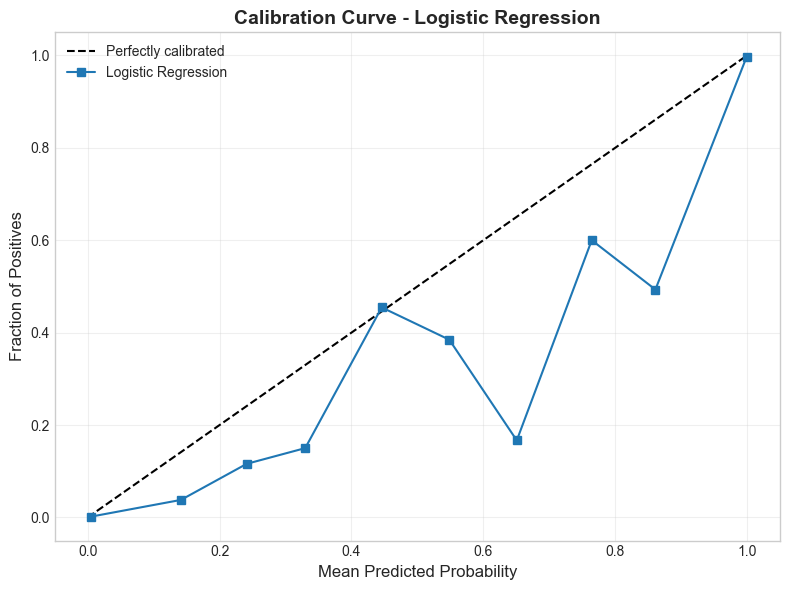


[OUTPUT] Calibration Bin Analysis:
 Bin  Predicted_Prob  Actual_Fraction  Deviation  Abs_Deviation  Sample_Count
   1        0.005083         0.001732  -0.003351       0.003351         43890
   2        0.141358         0.037879  -0.103479       0.103479           264
   3        0.241064         0.115942  -0.125121       0.125121            69
   4        0.329853         0.150000  -0.179853       0.179853            20
   5        0.445879         0.454545   0.008666       0.008666            11
   6        0.548413         0.384615  -0.163798       0.163798            13
   7        0.650744         0.166667  -0.484078       0.484078            12
   8        0.764456         0.600000  -0.164456       0.164456            20
   9        0.860990         0.493151  -0.367840       0.367840            73
  10        0.999366         0.996791  -0.002574       0.002574         13713


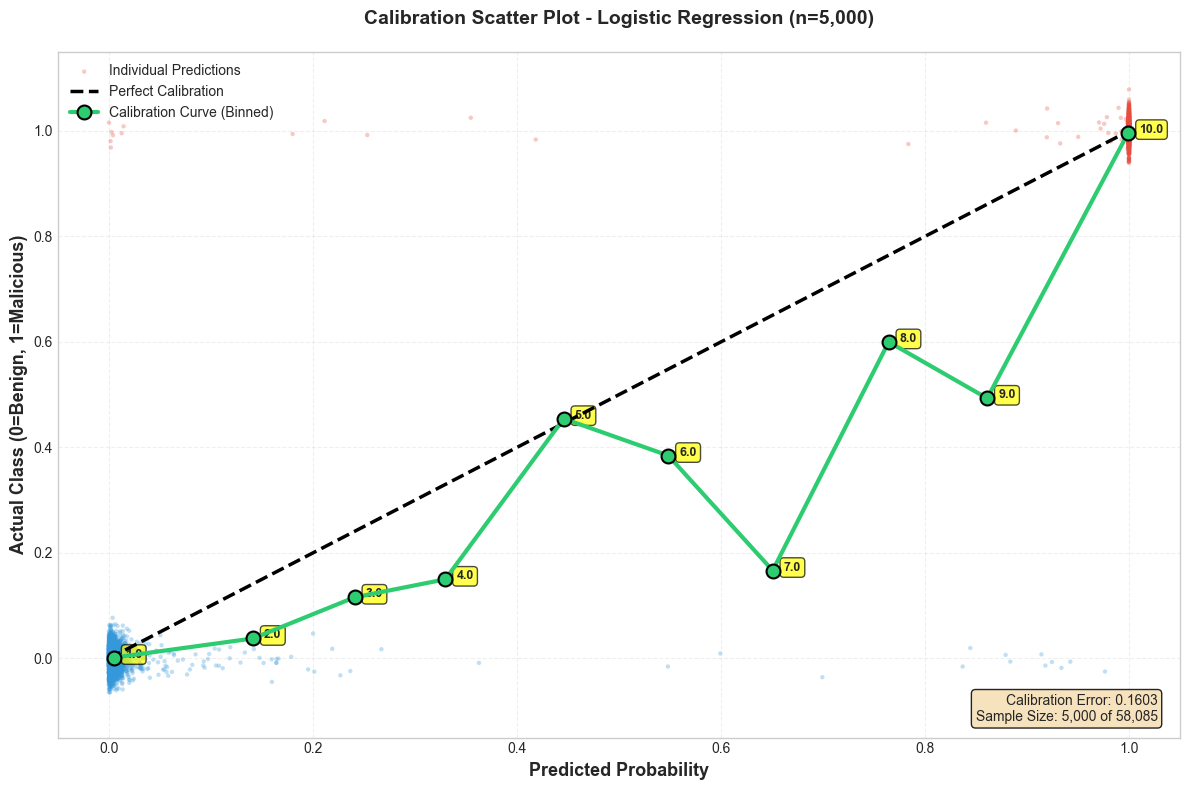


[OUTPUT] Calibration Interpretation:
--------------------------------------------------------------------------------
Overall Calibration: POOR - Model probabilities need recalibration
Mean Absolute Error: 0.1603

Under-calibrated bins (predicts HIGHER than actual): [2, 3, 4, 6, 7, 8, 9]
  → Model is TOO CONFIDENT - actual malicious rate is LOWER
  → Predicted probs: [0.141 0.241 0.33  0.548 0.651 0.764 0.861]

Most reliable: Bin 10.0 (~99.94%, dev=-0.0026)
Least reliable: Bin 7.0 (~65.07%, dev=-0.4841)

[OUTPUT] Scatter Plot Legend:
• Blue dots: Benign URLs (label=0)
• Red dots: Malicious URLs (label=1)
• Green line: Average calibration (binned predictions)
• Black dashed: Perfect calibration reference
• Points with jitter added for visibility

[OUTPUT] Mean calibration error: 0.1603


In [ ]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 6.1 PROBABILITY CALIBRATION - LOGISTIC REGRESSION"))

# INPUT
print(f"[INPUT] Validation samples: {len(X_val):,}")

# Get predictions on validation set
y_val_proba_lr = best_lr.predict_proba(X_val)[:, 1]

# Calculate calibration curve
prob_true, prob_pred = calibration_curve(y_val, y_val_proba_lr, n_bins=10, strategy='uniform')

# Calibration
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
ax.plot(prob_pred, prob_true, 's-', label='Logistic Regression')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title('Calibration Curve - Logistic Regression', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate calibration error
calibration_error = np.mean(np.abs(prob_true - prob_pred))

# OUTPUT
print(f"\n[OUTPUT] Mean calibration error: {calibration_error:.4f}")

# Calibrated model 
calibrated_lr = best_lr

### 6.2 Threshold Optimization (Maximize F1)
Select the decision threshold on validation data that maximizes F1 score.

## 6.2 THRESHOLD OPTIMIZATION - LOGISTIC REGRESSION


[INPUT] Finding optimal threshold on validation set
[INPUT] Default threshold: 0.5


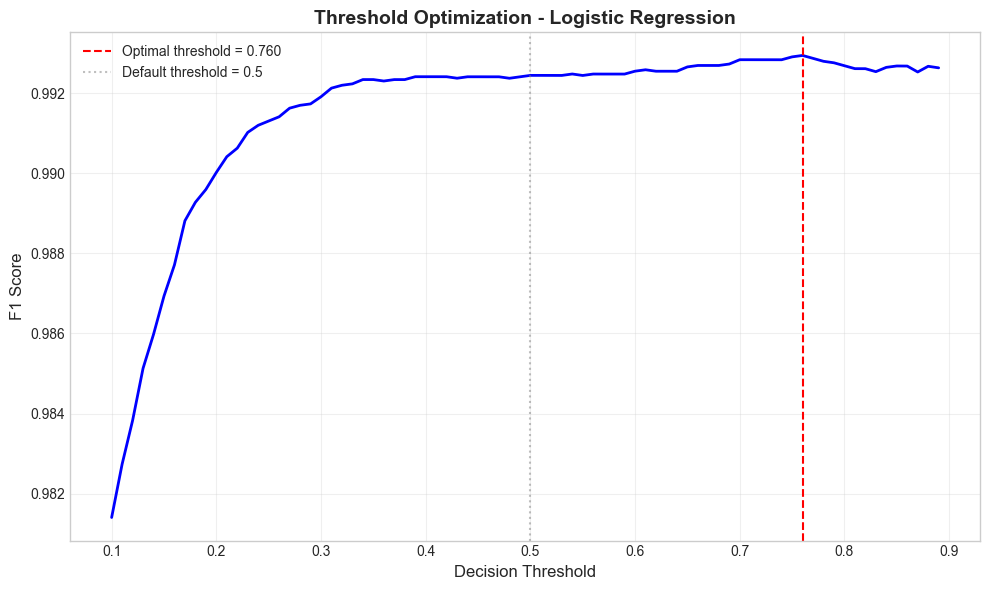


[OUTPUT] Optimal threshold: 0.760
[OUTPUT] F1 score at optimal threshold: 0.9929
[OUTPUT] F1 score at default threshold (0.5): 0.9924
[OUTPUT] Improvement: 0.0005


In [ ]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 6.2 THRESHOLD OPTIMIZATION - LOGISTIC REGRESSION"))

# INPUT
print(f"\n[INPUT] Finding optimal threshold on validation set")
print(f"[INPUT] Default threshold: 0.5")

# Get predicted probabilities on validation set
y_val_proba_lr = calibrated_lr.predict_proba(X_val)[:, 1]

# Test different thresholds
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for threshold in thresholds:
    y_pred_threshold = (y_val_proba_lr >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred_threshold)
    f1_scores.append(f1)

# Find optimal threshold
optimal_idx = np.argmax(f1_scores)
optimal_threshold_lr = thresholds[optimal_idx]
optimal_f1_lr = f1_scores[optimal_idx]

# hreshold vs F1
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, f1_scores, 'b-', linewidth=2)
ax.axvline(optimal_threshold_lr, color='r', linestyle='--', 
           label=f'Optimal threshold = {optimal_threshold_lr:.3f}')
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.5, label='Default threshold = 0.5')
ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Threshold Optimization - Logistic Regression', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# OUTPUT
print(f"\n[OUTPUT] Optimal threshold: {optimal_threshold_lr:.3f}")
print(f"[OUTPUT] F1 score at optimal threshold: {optimal_f1_lr:.4f}")

# Compare with default threshold
y_pred_default = (y_val_proba_lr >= 0.5).astype(int)
default_f1 = f1_score(y_val, y_pred_default)
print(f"[OUTPUT] F1 score at default threshold (0.5): {default_f1:.4f}")
print(f"[OUTPUT] Improvement: {(optimal_f1_lr - default_f1):.4f}")

## Section 7: Model Evaluation
Evaluate trained models on the held-out test set using multiple performance metrics.

### 7.1 Performance Metrics
Calculate Accuracy, Precision, Recall, F1-Score, ROC-AUC, and PR-AUC for each model.

In [24]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 7.1 PERFORMANCE METRICS - LOGISTIC REGRESSION"))

# INPUT
print(f"[INPUT] Test samples: {len(X_test):,}")
print(f"[INPUT] Optimal threshold: {optimal_threshold_lr:.3f}")

# Get predictions on test set
y_test_proba_lr = calibrated_lr.predict_proba(X_test)[:, 1]
y_test_pred_lr = (y_test_proba_lr >= optimal_threshold_lr).astype(int)

# Calculate metrics
accuracy_lr = accuracy_score(y_test, y_test_pred_lr)
precision_lr = precision_score(y_test, y_test_pred_lr)
recall_lr = recall_score(y_test, y_test_pred_lr)
f1_lr = f1_score(y_test, y_test_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_test_proba_lr)
pr_auc_lr = average_precision_score(y_test, y_test_proba_lr)

# OUTPUT
print(f"Accuracy:  {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1-Score:  {f1_lr:.4f}")
print(f"ROC-AUC:   {roc_auc_lr:.4f}")
print(f"PR-AUC:    {pr_auc_lr:.4f}")

# Classification report
print(f"\n[OUTPUT] Classification:")
print(classification_report(y_test, y_test_pred_lr, target_names=['Benign', 'Malicious']))

## 7.1 PERFORMANCE METRICS - LOGISTIC REGRESSION

[INPUT] Test samples: 75,940
[INPUT] Optimal threshold: 0.760
Accuracy:  0.9969
Precision: 0.9933
Recall:    0.9917
F1-Score:  0.9925
ROC-AUC:   0.9990
PR-AUC:    0.9984

[OUTPUT] Classification:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     59980
   Malicious       0.99      0.99      0.99     15960

    accuracy                           1.00     75940
   macro avg       1.00      0.99      1.00     75940
weighted avg       1.00      1.00      1.00     75940



### 7.2 Confusion Matrices
Visualize true positives, true negatives, false positives, and false negatives for each model.

## 7.2 CONFUSION MATRIX - LOGISTIC REGRESSION

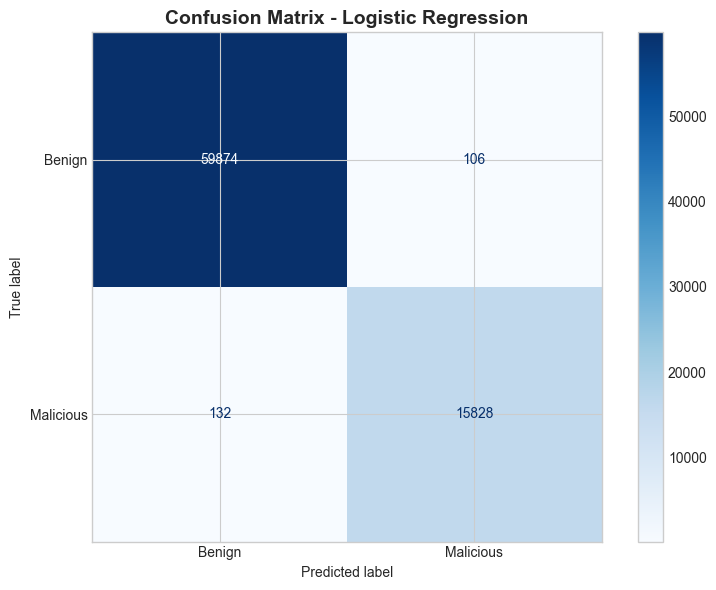

True Negatives:  59,874
False Positives: 106
False Negatives: 132
True Positives:  15,828


In [25]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 7.2 CONFUSION MATRIX - LOGISTIC REGRESSION"))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Benign', 'Malicious'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# OUTPUT
print(f"True Negatives:  {cm_lr[0, 0]:,}")
print(f"False Positives: {cm_lr[0, 1]:,}")
print(f"False Negatives: {cm_lr[1, 0]:,}")
print(f"True Positives:  {cm_lr[1, 1]:,}")

### 7.3 ROC Curves
Plot Receiver Operating Characteristic curves comparing all models.

## 7.3 ROC CURVE - LOGISTIC REGRESSION

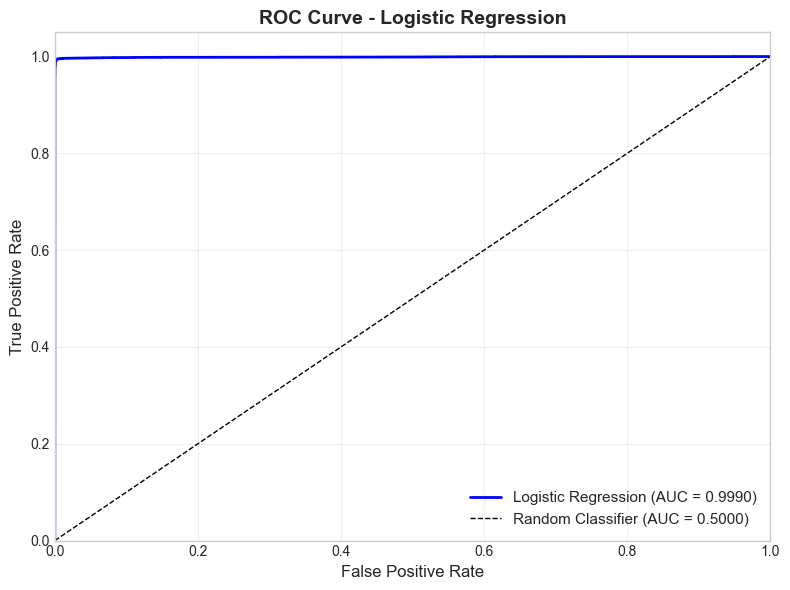


[OUTPUT] ROC-AUC Score: 0.9990


In [26]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 7.3 ROC CURVE - LOGISTIC REGRESSION"))

# Calculate ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_proba_lr)

# Plot ROC curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_lr, tpr_lr, 'b-', linewidth=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5000)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

# OUTPUT
print(f"\n[OUTPUT] ROC-AUC Score: {roc_auc_lr:.4f}")

### 7.4 Precision-Recall Curves
Plot Precision-Recall curves, especially important for imbalanced datasets.

## 7.4 PRECISION-RECALL CURVE - LOGISTIC REGRESSION

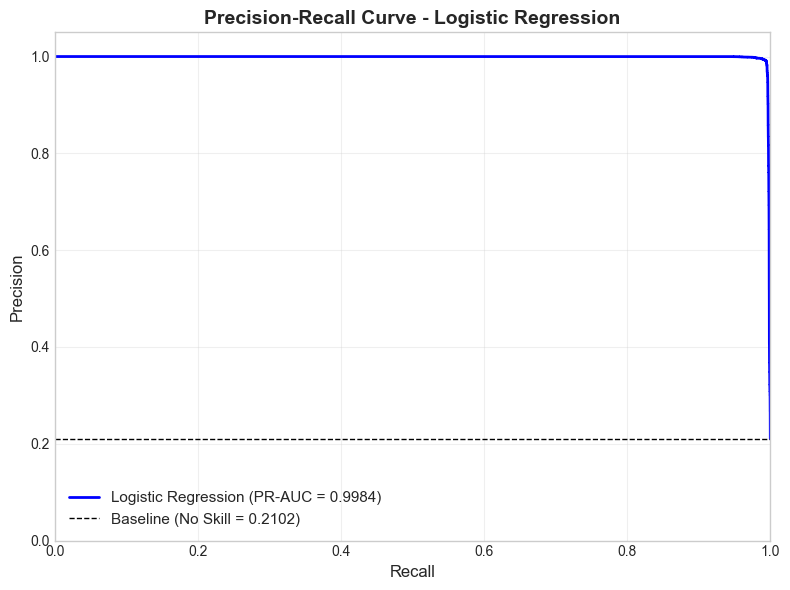


[OUTPUT] PR-AUC Score: 0.9984
[OUTPUT] Baseline (positive class ratio): 0.2102


In [27]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 7.4 PRECISION-RECALL CURVE - LOGISTIC REGRESSION"))

# Calculate PR curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_test_proba_lr)

# Plot PR curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_curve, precision_curve, 'b-', linewidth=2, 
        label=f'Logistic Regression (PR-AUC = {pr_auc_lr:.4f})')

# Baseline
baseline = y_test.sum() / len(y_test)
ax.plot([0, 1], [baseline, baseline], 'k--', linewidth=1, 
        label=f'Baseline (No Skill = {baseline:.4f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve - Logistic Regression', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

# OUTPUT
print(f"\n[OUTPUT] PR-AUC Score: {pr_auc_lr:.4f}")
print(f"[OUTPUT] Baseline (positive class ratio): {baseline:.4f}")

### 7.5 Inference Latency Measurement
Measure prediction time per URL to ensure the model meets low-latency requirements.

In [28]:
from IPython.display import display, Markdown, HTML
display(Markdown("## 7.5 INFERENCE LATENCY - LOGISTIC REGRESSION"))

# INPUT
print(f"[INPUT] Test samples: {len(X_test):,}")

# Measure prediction time
n_iterations = 100
times = []

for _ in range(n_iterations):
    start = time.time()
    _ = calibrated_lr.predict_proba(X_test)
    end = time.time()
    times.append(end - start)

# Calculate statistics
mean_batch_time = np.mean(times)
std_batch_time = np.std(times)
per_url_time = mean_batch_time / len(X_test) * 1000  # Convert to milliseconds

# OUTPUT
print(f"Batch size: {len(X_test):,} URLs")
print(f"Mean batch time: {mean_batch_time*1000:.2f} ± {std_batch_time*1000:.2f} ms")
print(f"Per URL latency: {per_url_time:.4f} ms")
print(f"Throughput: {len(X_test)/mean_batch_time:.0f} URLs/second")

## 7.5 INFERENCE LATENCY - LOGISTIC REGRESSION

[INPUT] Test samples: 75,940
Batch size: 75,940 URLs
Mean batch time: 279.00 ± 7.77 ms
Per URL latency: 0.0037 ms
Throughput: 272191 URLs/second


## Section 8: Results & Comparative Analysis
Compare model performance and select the best model.

### 8.1 Model Comparison Table

### 8.2 Best Model Selection
Select the final model based on F1 score, ROC-AUC, and inference latency criteria.

### 8.3 Feature Importance Analysis
Analyze which lexical features contribute most to malicious URL detection.